In [1]:
# Reference URL:-- https://medium.com/@abhishekjainindore24/all-about-decision-trees-80ea55e37fef

# A decision tree is a supervised learning algorithm used for both classification and regression tasks. 
# It has a hierarchical tree structure which consists of a root node, branches, internal nodes and leaf nodes.

# Key Components:

# Root Node: The top node in the tree that represents the best feature to split the data.
# Internal Nodes: Represent the features used for splitting the data based on specific decision rules.
# Leaf Nodes: Terminal nodes that represent the predicted outcome (class label or numerical value).
# Branches: Connections between nodes representing the possible values of the features.

# How Decision Trees Work?
# The process of creating a decision tree involves:

# Selecting the Best Attribute: Using a metric like Gini impurity, entropy, or information gain, the best attribute to split 
# the data is selected.
# Splitting the Dataset: The dataset is split into subsets based on the selected attribute.
# Repeating the Process: The process is repeated recursively for each subset, creating a new internal node or 
# leaf node until a stopping criterion is met (e.g., all instances in a node belong to the same class or a predefined depth is reached).

# A leaf node in a decision tree is the terminal node at the bottom of the tree, where no further splits are made. 
# Leaf nodes represent the final output or prediction of the decision tree. Once a data point reaches a leaf node, 
# a decision or prediction is made based on the majority class (for classification) or the average value (for regression) 
# of the data points that reach that leaf.

# To check mathematically if any split is pure split or not we use entropy or gini impurity. 
# Information Gain helps us to determine which features need to be selected.

# Entropy:-- 

# In the context of decision trees, entropy is often employed as a criterion to decide how to split data points at each node, 
# aiming to create subsets that are more homogeneous with respect to the target variable.

# Entropy is a measure of uncertainty or disorder. A low entropy indicates a more ordered or homogeneous set, 
# while a high entropy signifies greater disorder or diversity. In the context of a decision tree, 
# the goal is to reduce entropy by selecting features and split points that result in more ordered subsets.

# Entropy values range from 0 to 1. 

# The minimum entropy (0) occurs when all instances belong to a single class, making the set perfectly ordered. 
# The maximum entropy (1) occurs when instances are evenly distributed across all classes, creating a state of maximum disorder.

# At each node of a decision tree, the algorithm evaluates the entropy for each feature and split point. 
# The feature and split point that result in the largest reduction in entropy are chosen for the split. 
# The reduction in entropy is often referred to as Information Gain and is calculated as the difference between the entropy before and after the split.

# Important:--
# The minimum value of entropy is 0.
# Thus, for different numbers of classes:
# For 2 classes (binary classification): maximum entropy is 1.
# For 3 classes: maximum entropy is log⁡2(3)≈1.585
# For 4 classes: maximum entropy is log⁡2(4)=2 and so on

# Gini Impurity:--
    
# Gini impurity is a measure of the impurity or disorder in a set of elements, commonly used in decision tree algorithms, especially for classification tasks. 
# It quantifies the likelihood of misclassification of a randomly chosen element in the dataset.

# A lower Gini impurity suggests a more homogeneous set of elements within the node, making it an attractive split in a decision tree. 
# Decision tree algorithms aim to minimise the Gini impurity at each node, selecting the feature and split point that results in the lowest impurity.

# Important:--
# G = 0 indicates a perfectly pure node (all elements belong to the same class).
# G = 0.5 indicates maximum impurity (elements are evenly distributed among all classes)

# Most Important Point:--
# If our dataset is huge, we should choose Gini impurity as its calculation is much simpler compared to entropy
# Decision Tree is a terrible model if your dataset is small (because it will tend to overfit) 

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("tennis.csv")
df.head(5)

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes


In [4]:
df.shape

(14, 5)

In [5]:
# Performing Label Encoding on all the columns of the dataset columns

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df = df.apply(le.fit_transform)
df.head(5)

# 2. Encode categorical variables (the other way)
# le = LabelEncoder()
# for col in df.columns:
#     df[col] = le.fit_transform(df[col])

,outlook,temp,humidity,windy,play
0,2,1,0,0,0
1,2,1,0,1,0
2,0,1,0,0,1
3,1,2,0,0,1
4,1,0,1,0,1


In [6]:
# Define independent and dependent variable 

X = df.drop("play", axis=1)
y = df["play"]

In [7]:
X.head(5)

,outlook,temp,humidity,windy
0,2,1,0,0
1,2,1,0,1
2,0,1,0,0
3,1,2,0,0
4,1,0,1,0


In [8]:
y.head(5)

0    0
1    0
2    1
3    1
4    1
Name: play, dtype: int64

In [9]:
# Do a train-test-split of data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [10]:
# Decision Tree with Entropy (Information Gain)

from sklearn.tree import DecisionTreeClassifier

dt_entropy = DecisionTreeClassifier(criterion="entropy")
dt_entropy.fit(X_train, y_train)
y_pred_entropy = dt_entropy.predict(X_test)
y_prob_entropy = dt_entropy.predict_proba(X_test)[:,1]

In [11]:
# Decision Tree with Gini

dt_gini = DecisionTreeClassifier(criterion="gini")
dt_gini.fit(X_train, y_train)
y_pred_gini = dt_gini.predict(X_test)
y_prob_gini = dt_gini.predict_proba(X_test)[:,1]

In [12]:
# Check Accuracy Score of Both Entropy (IG) and Gini

from sklearn.metrics import roc_curve, auc, accuracy_score

print("Entropy Accuracy:", accuracy_score(y_test, y_pred_entropy))
print("Gini Accuracy:", accuracy_score(y_test, y_pred_gini))

Entropy Accuracy: 0.6666666666666666
Gini Accuracy: 0.6666666666666666


[Text(0.3333333333333333, 0.9, 'x[0] <= 0.5\nentropy = 0.946\nsamples = 11\nvalue = [4, 7]'),
 Text(0.2222222222222222, 0.7, 'entropy = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.2777777777777778, 0.8, 'True  '),
 Text(0.4444444444444444, 0.7, 'x[2] <= 0.5\nentropy = 1.0\nsamples = 8\nvalue = [4, 4]'),
 Text(0.38888888888888884, 0.8, '  False'),
 Text(0.2222222222222222, 0.5, 'x[1] <= 1.5\nentropy = 0.811\nsamples = 4\nvalue = [3, 1]'),
 Text(0.1111111111111111, 0.3, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.3333333333333333, 0.3, 'x[3] <= 0.5\nentropy = 1.0\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2222222222222222, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4444444444444444, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.6666666666666666, 0.5, 'x[3] <= 0.5\nentropy = 0.811\nsamples = 4\nvalue = [1, 3]'),
 Text(0.5555555555555556, 0.3, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.7777777777777778, 0.3, 'x[1] <= 1.0\nentropy = 1.0\nsa

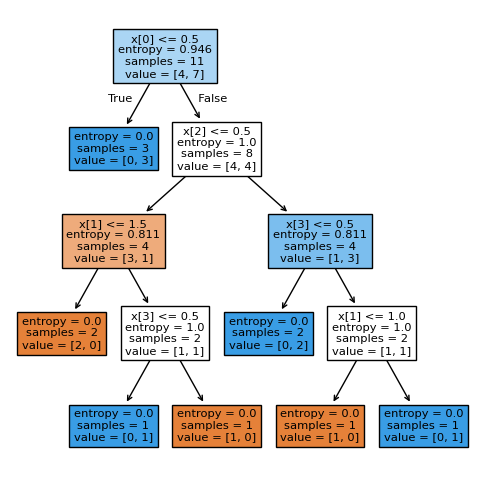

In [13]:
# Plot decision tree for Entropy
import matplotlib.pyplot as plt
from sklearn import tree

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6,6), dpi=100)
tree.plot_tree(dt_entropy, filled=True)

[Text(0.4, 0.9, 'x[0] <= 0.5\ngini = 0.463\nsamples = 11\nvalue = [4, 7]'),
 Text(0.3, 0.7, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.35, 0.8, 'True  '),
 Text(0.5, 0.7, 'x[1] <= 1.5\ngini = 0.5\nsamples = 8\nvalue = [4, 4]'),
 Text(0.45, 0.8, '  False'),
 Text(0.2, 0.5, 'x[2] <= 0.5\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.3, 0.3, 'x[3] <= 0.5\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.5, 'x[2] <= 0.5\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.7, 0.3, 'x[3] <= 0.5\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.6, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.9, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]')]

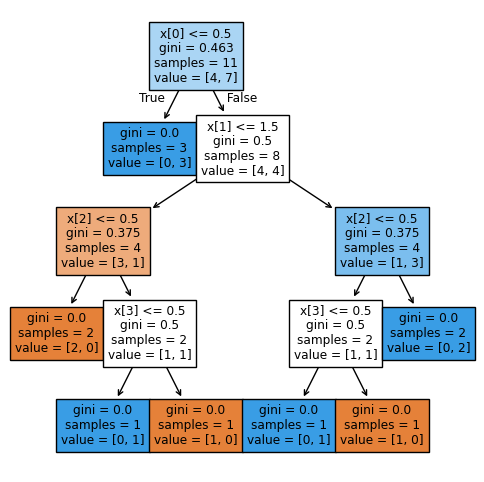

In [14]:
# Plot Decision Tree for Gini
import matplotlib.pyplot as plt
from sklearn import tree

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6,6), dpi=100)
tree.plot_tree(dt_gini, filled=True)

In [15]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


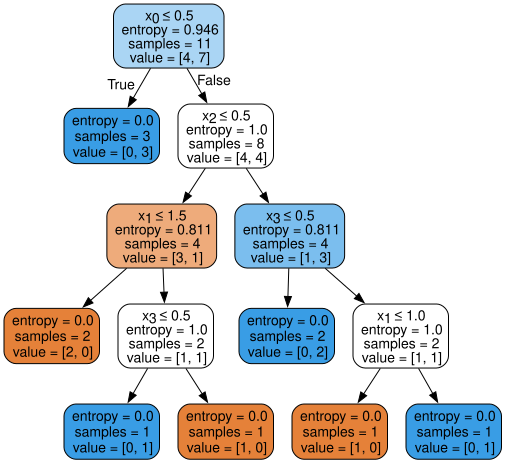

In [16]:
# Using Graphviz for Plot Decision Tree for Entropy
import graphviz
from sklearn.tree import export_graphviz

# Export tree to DOT format
dot_data = export_graphviz(
    dt_entropy,
    filled=True,
    rounded=True,
    special_characters=True
)

# 5. Render with Graphviz
graph = graphviz.Source(dot_data)
graph

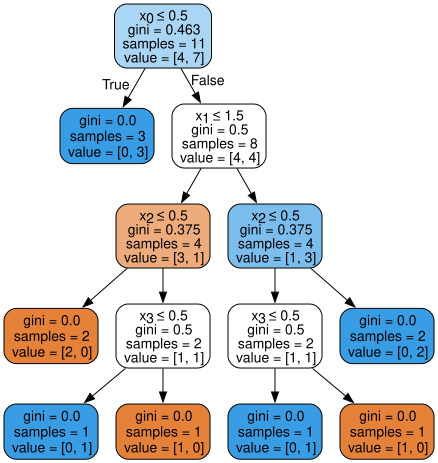

In [17]:
# Using Graphviz for Plot Decision Tree for Entropy
import graphviz
from sklearn.tree import export_graphviz

# Export tree to DOT format
dot_data = export_graphviz(
    dt_gini,
    filled=True,
    rounded=True,
    special_characters=True
)

# 5. Render with Graphviz
graph_gini = graphviz.Source(dot_data)
graph_gini

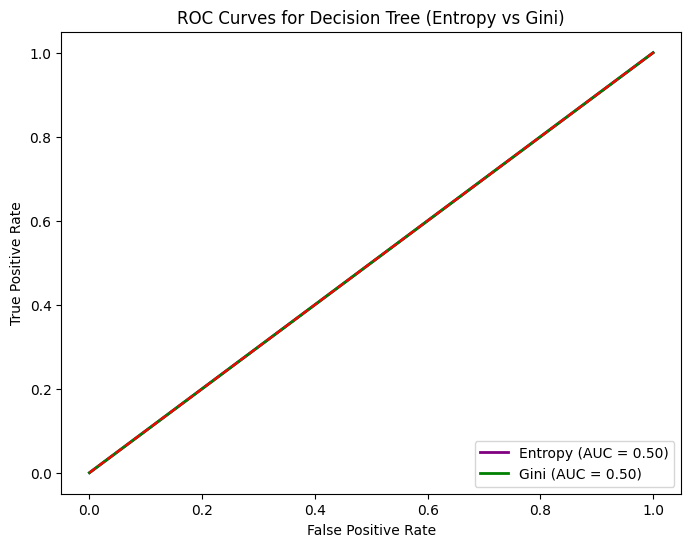

In [18]:
# 7. ROC–AUC curves for Both Entropy (IG) and Gini

from sklearn.metrics import roc_curve, auc, accuracy_score
import matplotlib.pyplot as plt

fpr_e, tpr_e, _ = roc_curve(y_test, y_prob_entropy)
roc_auc_e = auc(fpr_e, tpr_e)

fpr_g, tpr_g, _ = roc_curve(y_test, y_prob_entropy)
roc_auc_g = auc(fpr_g, tpr_g)

plt.figure(figsize=(8,6))
plt.plot(fpr_e, tpr_e, color="purple", lw=2, label=f"Entropy (AUC = {roc_auc_e:.2f})")
plt.plot(fpr_g, tpr_g, color="green", lw=2, label=f"Gini (AUC = {roc_auc_g:.2f})")
plt.plot([0,1],[0,1], color="red", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Decision Tree (Entropy vs Gini)")
plt.legend(loc="lower right")
plt.show()

In [19]:
# Above message usually appears when you try to compute an ROC curve but your test labels (y_true) contain only one class (e.g., all 1s or all 0s).
# - If you see only {1} or {0}, that’s the problem.
# - Use stratified splitting (stratified K-
# Ensure both classes appear in train and test sets

# Check your train/test split to check value
print("Unique values in y_test:", set(y_test))

Unique values in y_test: {0, 1}


Stratified K-Fold accuracies for entropy = [0.66666667 0.33333333 0.33333333 0.33333333 0.5       ]
Mean Accuracy % (entropy): 43.33
----------------------------------------------
Stratified K-Fold accuracies for gini = [0.66666667 0.33333333 0.33333333 0.33333333 0.5       ]
Mean Accuracy % (gini): 43.33
----------------------------------------------


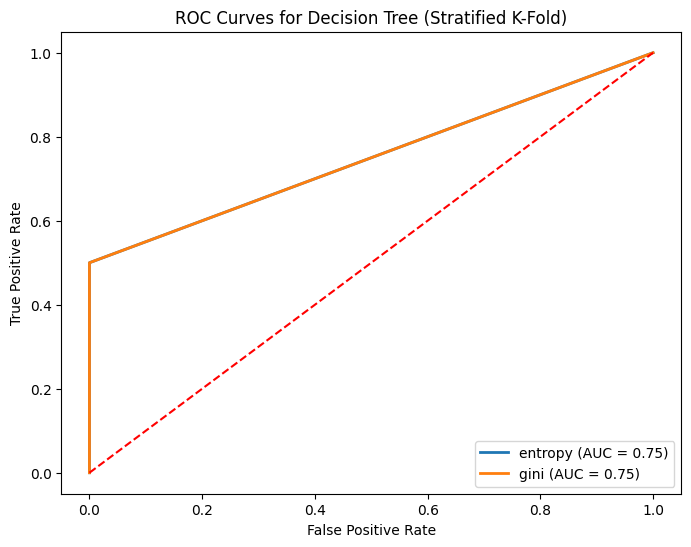

In [20]:
#  Stratified K-Fold Decision Tree code

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("tennis.csv")

# Encode categorical variables
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("play", axis=1)
y = df["play"]

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compare Entropy vs Gini using Stratified K-Fold
for criterion in ["entropy", "gini"]:
    model = DecisionTreeClassifier(criterion=criterion, random_state=42)
    cv_score = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
    mean_accuracy = round(cv_score.mean() * 100, 2)
    print(f"Stratified K-Fold accuracies for {criterion} = {cv_score}")
    print(f"Mean Accuracy % ({criterion}): {mean_accuracy}")
    print("----------------------------------------------")

# Plot ROC–AUC curves (using one stratified fold for visualization)
plt.figure(figsize=(8,6))
for criterion in ["entropy", "gini"]:
    model = DecisionTreeClassifier(criterion=criterion, random_state=42)
    # Take the first fold for ROC visualization
    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{criterion} (AUC = {roc_auc:.2f})')
        break  # only plot first fold for clarity

plt.plot([0,1],[0,1], color="red", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Decision Tree (Stratified K-Fold)")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Dataset each column explained

Variable	Description
age	--     Age of the patient in years
sex	--     Gender of the patient (0 = male, 1 = female)
cp	Chest pain type:
0: Typical angina
1: Atypical angina
2: Non-anginal pain
3: Asymptomatic
trestbps --	Resting blood pressure in mm Hg
chol	--  Serum cholesterol in mg/dl
fbs	Fasting blood sugar level, categorised as above 120 mg/dl (1 = true, 0 = false)
restecg	Resting electrocardiographic results:
0: Normal
1: Having ST-T wave abnormality
2: Showing probable or definite left ventricular hypertrophy
thalach	--  Maximum heart rate achieved during a stress test
exang	--  Exercise-induced angina (1 = yes, 0 = no)
oldpeak	--  ST depression induced by exercise relative to rest
slope	Slope of the peak exercise ST segment:
0: Upsloping
1: Flat
2: Downsloping
ca	--   Number of major vessels (0-4) colored by fluoroscopy
thal -- Thalium stress test result:
0: Normal
1: Fixed defect
2: Reversible defect
3: Not described
target	--  Heart disease status (0 = no disease, 1 = presence of disease)

In [23]:
X = df.drop('target', axis=1)
y = df['target']

In [28]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [29]:
# Read dataset
df = pd.read_csv('heart.csv')
df.shape

(303, 14)

In [32]:
# Train-test split and use feature scaling Standard scaler 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
from sklearn.dummy import DummyClassifier

# Dummy Classifier (baseline)
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_prob_dummy = dummy.predict_proba(X_test)[:,1]

fpr_dummy, tpr_dummy, _ = roc_curve(y_test, y_prob_dummy)
roc_auc_dummy = auc(fpr_dummy, tpr_dummy)
print(roc_auc_dummy)

0.5


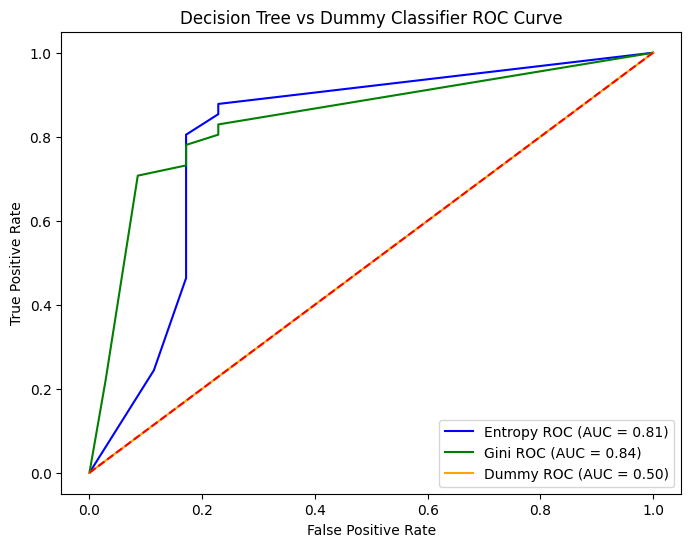


Decision Tree (Entropy) Evaluation:
Confusion Matrix:
 [[29  6]
 [ 8 33]]
Accuracy: 0.8157894736842105
F1 Score: 0.825
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.81        35
           1       0.85      0.80      0.82        41

    accuracy                           0.82        76
   macro avg       0.81      0.82      0.82        76
weighted avg       0.82      0.82      0.82        76


Decision Tree (Gini) Evaluation:
Confusion Matrix:
 [[29  6]
 [ 9 32]]
Accuracy: 0.8026315789473685
F1 Score: 0.810126582278481
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.83      0.79        35
           1       0.84      0.78      0.81        41

    accuracy                           0.80        76
   macro avg       0.80      0.80      0.80        76
weighted avg       0.81      0.80      0.80        76


Dummy Classifier Evaluation:
Confusion Matrix:
 

In [37]:
# 1. Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report,
    accuracy_score, f1_score
)
import matplotlib.pyplot as plt

# 2. Load dataset
df = pd.read_csv("heart.csv")

# 3. Define features and target
X = df.drop(columns=['target'])
y = df['target']

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Decision Tree (Entropy)
dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
dt_entropy.fit(X_train, y_train)

# 6. Decision Tree (Gini)
dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_gini.fit(X_train, y_train)

# 7. Dummy Classifier
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)

# 8. Predictions
y_pred_entropy = dt_entropy.predict(X_test)
y_pred_gini = dt_gini.predict(X_test)
y_pred_dummy = dummy.predict(X_test)

# 9. Probabilities for ROC
y_prob_entropy = dt_entropy.predict_proba(X_test)[:,1]
y_prob_gini = dt_gini.predict_proba(X_test)[:,1]
y_prob_dummy = dummy.predict_proba(X_test)[:,1]

# 10. ROC Curves
fpr_entropy, tpr_entropy, _ = roc_curve(y_test, y_prob_entropy)
roc_auc_entropy = auc(fpr_entropy, tpr_entropy)

fpr_gini, tpr_gini, _ = roc_curve(y_test, y_prob_gini)
roc_auc_gini = auc(fpr_gini, tpr_gini)

fpr_dummy, tpr_dummy, _ = roc_curve(y_test, y_prob_dummy)
roc_auc_dummy = auc(fpr_dummy, tpr_dummy)

plt.figure(figsize=(8,6))
plt.plot(fpr_entropy, tpr_entropy, color='blue',
         label=f'Entropy ROC (AUC = {roc_auc_entropy:.2f})')
plt.plot(fpr_gini, tpr_gini, color='green',
         label=f'Gini ROC (AUC = {roc_auc_gini:.2f})')
plt.plot(fpr_dummy, tpr_dummy, color='orange',
         label=f'Dummy ROC (AUC = {roc_auc_dummy:.2f})')
plt.plot([0,1],[0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree vs Dummy Classifier ROC Curve')
plt.legend(loc="lower right")
plt.show()

# 11. Evaluation metrics
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Evaluation:")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

evaluate_model("Decision Tree (Entropy)", y_test, y_pred_entropy)
evaluate_model("Decision Tree (Gini)", y_test, y_pred_gini)
evaluate_model("Dummy Classifier", y_test, y_pred_dummy)